In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from scholarlm.utils import (
    get_filenames_in_directory,
    load_and_process_results
)

%load_ext autoreload
%autoreload 2

INFO 03-24 19:34:35 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-24 19:34:49 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')
WARNING 03-24 19:34:49 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
palette = sns.color_palette("husl", 8)
cmap = ListedColormap(palette)

cluster_color_dict = {i: cmap(7 - i) for i in range(8)}
cluster_color_dict[-1] = 'grey'

color_dict = {'pond' : cmap(5), 'lake': cmap(1), 'wetland': cmap(7), 'other' : cmap(6)}

# This assumes tex is installed in your system, 
# if not, you may simply remove most of this, aside from font.size 
# (doing so, however, will break certain plotting functions)
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "font.serif": [],
    "text.usetex": True,
    "pgf.rcfonts": False,
    "font.size": 20
})

In [3]:
# For converting the various ecosystem labels in the dataset to a standardized set of labels:
# (pond, lake, wetland, other)
classification_dict = {
    'pond' : 'pond',
    'lake' : 'lake',
    'wetland' : 'wetland',
    'small water bodies or ponds' : 'pond',
    'pond or small lake' : 'pond',
    'wetland vs. lake' : None,
    'lakes' : 'lake',
    'shallow lake' : 'lake',
    'urban ponds' : 'pond',
    'shallow lakes' : 'lake',
    'karst pond' : 'pond',
    'small lake' : 'lake',
    'pothole' : 'other',
    'pools and ponds; bodri (italian term)' : 'pond',
    'temporary pond' : 'pond',
    'stormwater pond' : 'pond',
    'karst ponds' : 'pond',
    'subtropical shallow lake' : 'lake',
    'small lakes' : 'lake',
    'treatment cells in constructed wetlands' : 'wetland',
    'kettle hole' : 'other',
    'pond or reservoir' : 'pond',
    'lentic small water bodies' : 'pond',
    'pool' : 'other',
    'zbiornik(pond)' : 'pond',
    'permenant pond' : 'pond',
    'rock pools' : 'other',
    'dune ponds' : 'pond',
    'farm pond; small impoundment' : 'pond',
    'farm pond' : 'pond',
    'mediterranean wetland' : 'wetland',
    'small humic lakes' : 'lake',
    'high planktivory lake' : 'lake',
    'inland-lake' : 'lake',
    'pond/tundra pond' : 'pond',
    'lakes and reservoirs (broken into small and large)' : 'lake',
    'wetland' : 'wetland',
    'small (< 10 km2) seasonally ice-covered arctic lakes' : 'lake',
    'wetland; pond' : None,
    'peat lake' : 'lake',
    'small tropical lake' : 'lake',
    'meteorite crater ponds' : 'pond',
    'agricultural water reservoir' : 'pond',
    'coastal plain shallow lake' : 'lake',
    'residential pond' : 'pond',
    'small impoundment' : 'other',
    'small-sized lentic ecosystem; lake' : None,
    'reservoir' : 'other',
    'small acidic bog lake' : 'lake',
    'in-field pond' : 'pond',
    'temporary lake' : 'lake',
    'lake (reservoir)' : 'lake',
    'shallow subtropical lake' : 'lake',
    'wetland/lake' : None,
    'vernal pool' : 'other',
    'temporary lake/seasonal pond' : None,
    'permanent lake' : 'lake',
    'other' : 'other',
    'ponds' : 'pond',
    'deep refuge lake' : 'lake',
    'lake/pond' : None,
    'lagoon; shallow lake' : 'lake',
    'marsh' : 'wetland',
    'terporary wetland; also temparary pond' : None,
    'aquatic environment' : 'other',
    'near-natural ponds' : 'pond',
    'small-sized lentic ecosystem; wetland' : None,
    'reservoir' : 'other',
    'vernal pool' : 'other',
    'bog' : 'other',
    'impoundment' : 'other',
    'shallow lake' : 'lake',
    'river branch' : 'other',
    'basin' : 'other',
    'stream' : 'other',
    'constructed wetland' : 'wetland',
    'groundwater' : 'other',
    'watershed' : 'other',
    'river' : 'other',
    'brackish-water body' : 'other',
    'channel' : 'other',
    'peatland complex' : 'other',
    'peatland' : 'other',
    'permanent freshwater marsh' : 'wetland',
    'lagoon' : 'other'
}

### Load Manually Extracted Data

In [4]:
pond_df = pd.read_csv(
    "../data/pond/pond_data_corrected.csv",
    encoding_errors='ignore',
    index_col = 0
)
pond_df = pond_df.reset_index(drop=True)

id_cols = ['author', 'title', 'name', 'location', 'ecosystem', 'date', 'state']
pond_df[id_cols] = pond_df[id_cols].fillna('NA')

pond_df = pd.pivot_table(
    pond_df,
    index=id_cols,
    columns='attribute',
    values='value',
    aggfunc='first'
)

# Convert m2 to ha (what the external dataset uses)
pond_df['surface_area'] = pond_df['surface_area'] / 10000

# convert veg cover from percentage to proportion
pond_df['vegetation_cover'] = pond_df['vegetation_cover'] / 100

pond_df.dropna(axis=0, how='all', inplace=True)

pond_df = pond_df.loc[:, ['surface_area', 'max_depth', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']]

pond_data = pond_df.to_numpy()
pond_labels = pond_df.index.get_level_values('ecosystem').map(classification_dict).to_numpy()

valid_idx = ~pd.isna(pond_labels) & (pond_labels != 'other')
pond_data = pond_data[valid_idx]
pond_labels = pond_labels[valid_idx]


In [5]:
len(pond_data), len(pond_labels)

(1101, 1101)

### Load LLM Extracted Data

In [6]:
# ---------------------------------
# Load experiment results
# ---------------------------------

experiment_data_path = "../data/experiments/2026_03_04/pond_judged_combined_scores.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 100, "ha": 1, "mi^2": 258.999, "m^2": 1e-4, "acres": 0.404686},
    'vegetation_cover': {"percent": 1/100, "fraction": 1.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value",
    strict_unit_conversion=True
)


#extracted_df_scores = np.load("../data/experiments/2026_03_04/pond_judged_combined_scores.npy")
#extracted_df['confidence'] = extracted_df_scores

id_cols = ["entity_id", "ecosystem"]
extracted_data_df = pd.pivot_table(
    extracted_df,
    index=id_cols,
    columns="attribute",
    values="processed_value",
    aggfunc='first'
)


extracted_confidence_df = pd.pivot_table(
    extracted_df,
    index=id_cols,
    columns="attribute",
    values="confidence",
    aggfunc='first'
)


duplicate_mask = extracted_data_df.duplicated(keep="first")
extracted_data_df = extracted_data_df[~duplicate_mask]
extracted_confidence_df = extracted_confidence_df[~duplicate_mask]
extracted_data_df = extracted_data_df.loc[:, ['surface_area', 'max_depth', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']]
extracted_confidence_df = extracted_confidence_df.loc[:, ['surface_area', 'max_depth', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']]

pond_extracted_data = extracted_data_df.to_numpy()
pond_extracted_labels = extracted_data_df.index.get_level_values('ecosystem').map(classification_dict).to_numpy()
pond_extracted_confidence = extracted_confidence_df.prod(axis=1, skipna = True).to_numpy()

pond_extracted_idx = [i for i, label in enumerate(pond_extracted_labels) if label in ['pond', 'lake', 'wetland']]
pond_extracted_data = pond_extracted_data[pond_extracted_idx]
pond_extracted_labels = pond_extracted_labels[pond_extracted_idx]
pond_extracted_confidence = pond_extracted_confidence[pond_extracted_idx]

# Filter low confidence points
'''
confidence_threshold = 0.5
high_confidence_mask = pond_extracted_confidence >= confidence_threshold
pond_extracted_data = pond_extracted_data[high_confidence_mask]
pond_extracted_labels = pond_extracted_labels[high_confidence_mask]
pond_extracted_confidence = pond_extracted_confidence[high_confidence_mask]
'''

'\nconfidence_threshold = 0.5\nhigh_confidence_mask = pond_extracted_confidence >= confidence_threshold\npond_extracted_data = pond_extracted_data[high_confidence_mask]\npond_extracted_labels = pond_extracted_labels[high_confidence_mask]\npond_extracted_confidence = pond_extracted_confidence[high_confidence_mask]\n'

(array([593., 109.,  57.,  50.,  32.,  51.,  56.,  85., 118., 200.]),
 array([8.51097427e-13, 9.96067686e-02, 1.99213537e-01, 2.98820306e-01,
        3.98427074e-01, 4.98033843e-01, 5.97640612e-01, 6.97247380e-01,
        7.96854149e-01, 8.96460918e-01, 9.96067686e-01]),
 <BarContainer object of 10 artists>)

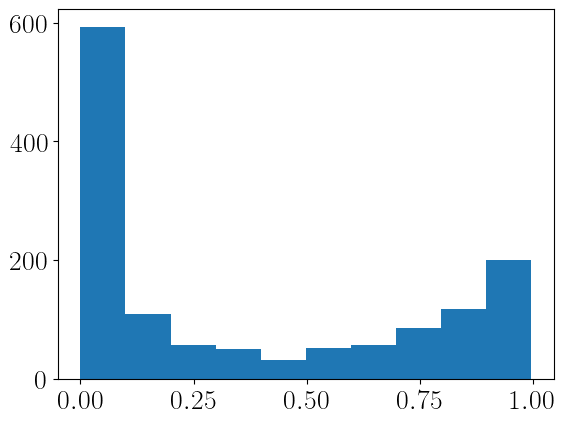

In [7]:
plt.hist(pond_extracted_confidence)

In [8]:
len(pond_extracted_data), len(pond_extracted_labels), len(pond_extracted_confidence)

(1351, 1351, 1351)

### Manual vs Extracted comparison

In [9]:
units_dict = {
    'surface_area': 'ha',
    'max_depth': 'm',
    'vegetation_cover': '',
    'ph': '',
    'tn': 'µg/L',
    'tp': 'µg/L',
    'chla': 'µg/L'
}

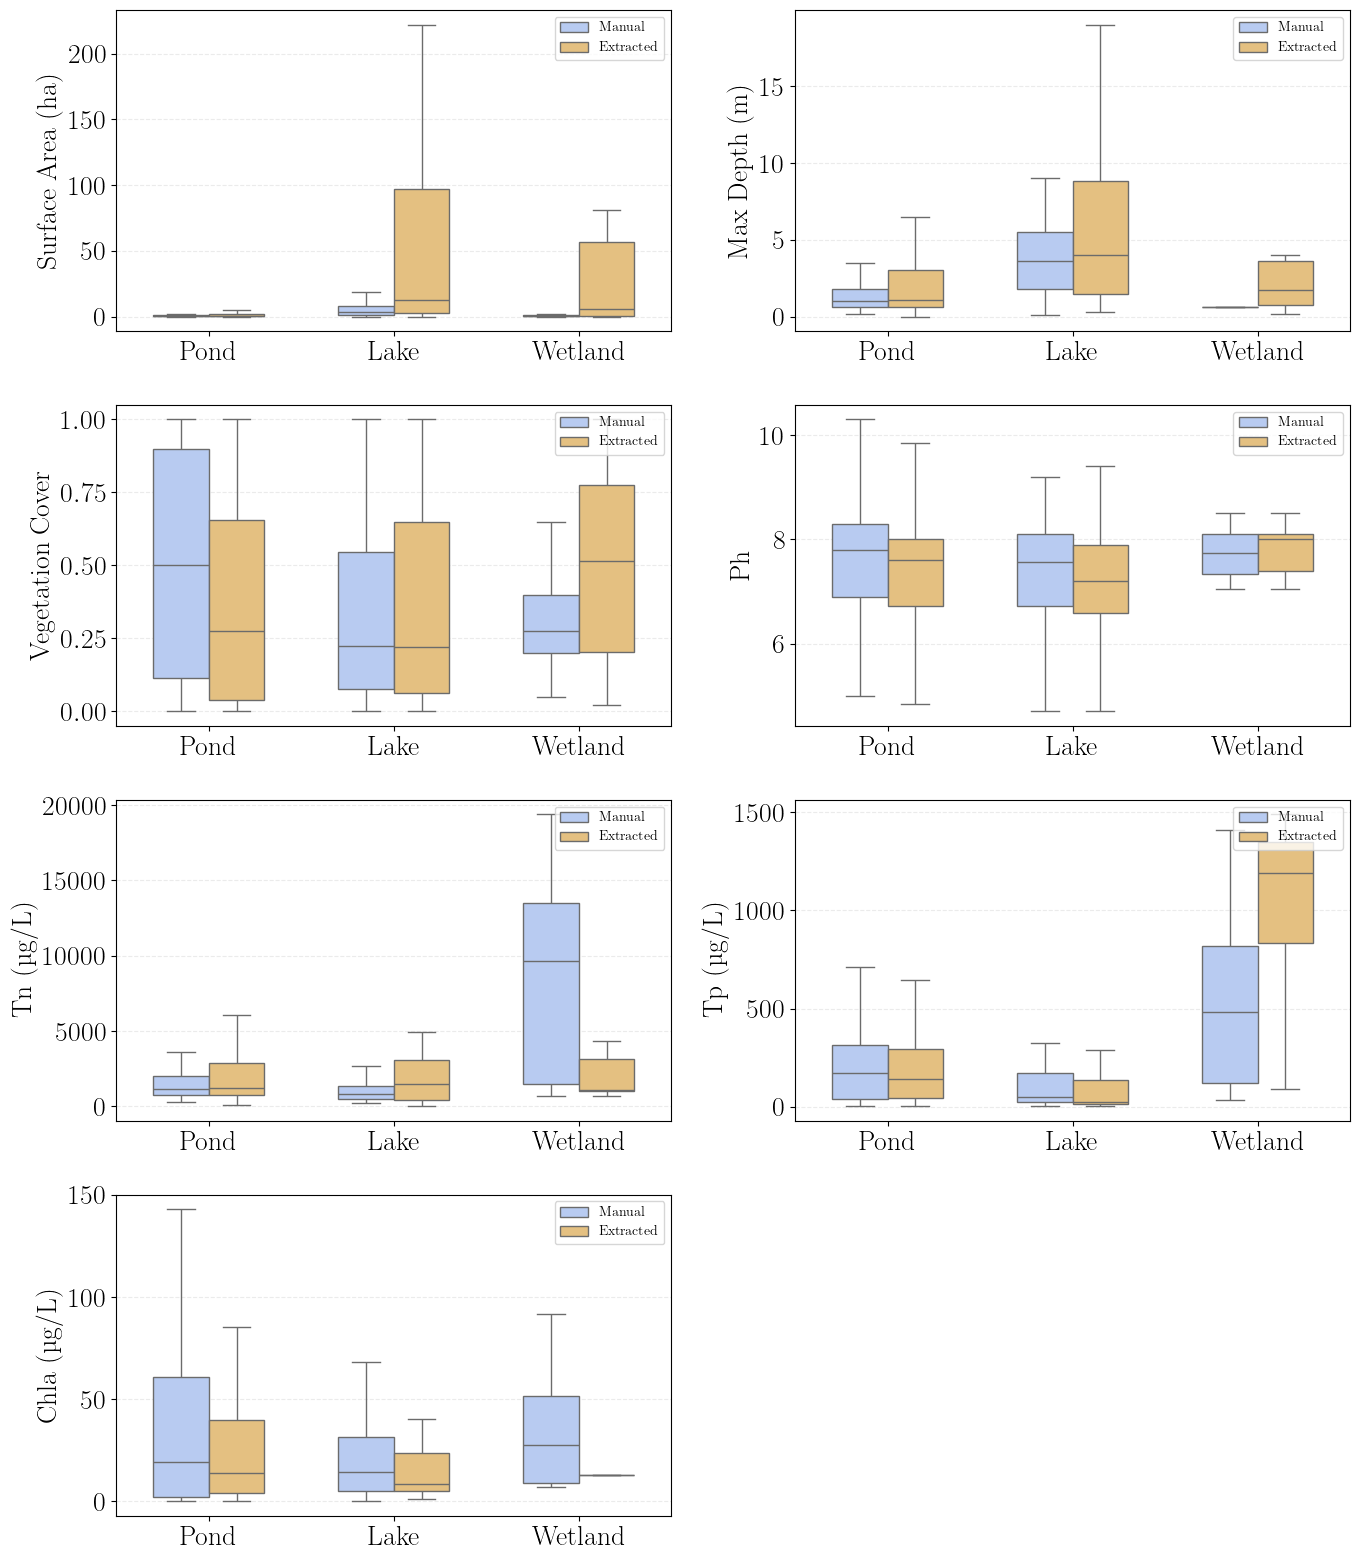

In [10]:
# Compare per-feature distributions using seaborn box plots
feature_names = pond_df.columns.tolist()
num_features = len(feature_names)
ncols = 2
nrows = (num_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten()

ecosystem_types = ['pond', 'lake', 'wetland']

# Aesthetic color scheme for manual vs extracted
colors = {'Manual': "#AFC8FA", 'Extracted': "#F5C470"}

for feature_idx, feature in enumerate(feature_names):
    ax = axes[feature_idx]
    
    # Prepare data as a long-form dataframe for seaborn
    plot_data = []
    
    for ecosystem in ecosystem_types:
        # Manual data
        manual_mask = pond_labels == ecosystem
        manual_feature = pond_data[manual_mask, feature_idx]
        manual_feature_clean = manual_feature[~np.isnan(manual_feature)]
        for val in manual_feature_clean:
            plot_data.append({'Ecosystem': ecosystem.capitalize(), 'Source': 'Manual', 'Value': val})
        
        # Extracted data
        extracted_mask = pond_extracted_labels == ecosystem
        extracted_feature = pond_extracted_data[extracted_mask, feature_idx]
        extracted_feature_clean = extracted_feature[~np.isnan(extracted_feature)]
        for val in extracted_feature_clean:
            plot_data.append({'Ecosystem': ecosystem.capitalize(), 'Source': 'Extracted', 'Value': val})
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create box plot with seaborn
    sns.boxplot(data=plot_df, x='Ecosystem', y='Value', hue='Source', ax=ax, 
                palette=colors, width=0.6, showfliers=False)
    
    # Set y-axis limits based on quartile ranges per ecosystem
    if len(plot_data) > 0:
        min_q1 = float('inf')
        max_q3 = float('-inf')
        
        # Find the minimum Q1 and maximum Q3 across all ecosystem-source combinations
        for ecosystem in ecosystem_types:
            for source in ['Manual', 'Extracted']:
                subset_values = [d['Value'] for d in plot_data 
                                if d['Ecosystem'] == ecosystem and d['Source'] == source]
                if len(subset_values) > 0:
                    q1 = np.percentile(subset_values, 25)
                    q3 = np.percentile(subset_values, 75)
                    min_q1 = min(min_q1, q1)
                    max_q3 = max(max_q3, q3)
        
        # Calculate margin based on overall IQR
        if min_q1 != float('inf') and max_q3 != float('-inf'):
            iqr = max_q3 - min_q1
            margin = iqr * 0.2
            y_min = min_q1 - margin
            y_max = max_q3 + margin
            ax.set_ylim(y_min, y_max)
    
    feature_units = units_dict.get(feature, '')
    ax.set_ylabel(feature.replace('_', ' ').title() + (f' ({feature_units})' if feature_units else ''))
    ax.set_xlabel('')
    #ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    
    # Style the plot
    ax.grid(True, alpha=0.25, linestyle='--', axis='y', zorder=0)
    ax.set_axisbelow(True)
    
    # Clean up legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='', fontsize=10, loc='upper right')

# Hide unused subplots
for idx in range(num_features, len(axes)):
    axes[idx].axis('off')

#plt.suptitle('Per-Feature Distributions: Manual vs. Extracted Data', 
#             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Other Data
Since the original paper also includes publically available lake and wetland data, we
include this for our analysis as well.

In [11]:
lake_df = pd.read_csv('../data/pond/meta/nla12_keyvariables_data.csv')
lake_physical = pd.read_csv('../data/pond/meta/nla2012_wide_phabmet_10202016.csv')
lake_chemical = pd.read_csv('../data/pond/meta/nla2012_waterchem_wide.csv')

veg_covers = []
for idt in lake_df.UID:
    res = lake_physical.loc[lake_physical.UID == idt, 'AMFCALL'].values
    if len(res) == 1:
        veg_covers.append(res[0])
    else:
        veg_covers.append(np.nan)
lake_df['veg_cover'] = veg_covers

phs = []
for idt in lake_df.UID:
    res = lake_chemical.loc[lake_chemical.UID == idt, 'PH_RESULT'].values
    if len(res) == 1:
        phs.append(res[0])
    else:
        phs.append(np.nan)
lake_df['pH'] = phs

select_features = ["AREA_HA", "INDEX_SITE_DEPTH", "veg_cover", "pH", "NTL_RESULT", "PTL_RESULT", "CHLX_RESULT"]
sub_lake_df = lake_df.loc[:, select_features]
sub_lake_df.columns = ["surface_area", "max_depth", "vegetation_cover", "ph", "tn", "tp", "chla"]

# Convert from mg/L to ug/L
sub_lake_df['tn'] = sub_lake_df['tn'] * 1000.0

sub_lake_df.dropna(axis=0, how='all', inplace=True)

lake_data = sub_lake_df.to_numpy()
lake_labels = np.array(['lake'] * lake_data.shape[0])

In [12]:
wetland_df = pd.read_csv('../data/pond/meta/nwca2011_aachar.csv')
wetland_vegetation = pd.read_csv('../data/pond/meta/nwca2011_vegmetrics.csv')
wetland_chemical = pd.read_csv('../data/pond/meta/nwca2011_waterchem.csv')
wetland_chl = pd.read_csv('../data/pond/meta/nwca2011_chla.csv')

surface_areas = wetland_df['AA_AREA'].values
depths = []
veg_covers = []
tns = []
tps = []
chls = []
phs = []
for uid in wetland_df.UID:
    res = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'MAX_H2O_DEPTH'].values
    if len(res) == 1:
        depths.append(res[0])
    else:
        depths.append(np.nan)
    
    #res = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'XCOV_H2O_NOVEG'].values
    res1 = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'XCOV_H2O_EMERGVEG'].values
    res2 = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'XCOV_H2O_AQVEG'].values
    if len(res1) == 1 and len(res2) == 1:
        veg_covers.append(res1[0] + res2[0])
    elif len(res1) == 1:
        veg_covers.append(res1[0])
    elif len(res2) == 1:
        veg_covers.append(res2[0])
    else:
        veg_covers.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'TN'].values
    if len(res) == 1:
        tns.append(res[0])
    else:
        tns.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'TP'].values
    if len(res) == 1:
        tps.append(res[0])
    else:
        tps.append(np.nan)
    
    res = wetland_chl.loc[wetland_chl.UID == uid, 'CHLA'].values
    if len(res) == 1:
        chls.append(res[0])
    else:
        chls.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'PH'].values
    if len(res) == 1:
        phs.append(res[0])
    else:
        phs.append(np.nan)

wetland_df['surface_area'] = np.nan
wetland_df['depth'] = depths
wetland_df['veg_cover'] = veg_covers
wetland_df['TN'] = tns
wetland_df['TP'] = tps
wetland_df['chl_a'] = chls
wetland_df['pH'] = phs

select_features = ["surface_area", "depth", "veg_cover", "pH", "TN", "TP", "chl_a"]
sub_wetland_df = wetland_df.loc[:, select_features]
sub_wetland_df.columns = ["surface_area", "max_depth", "vegetation_cover", "ph", "tn", "tp", "chla"]

# Convert from cm to m
# NOTE: I'm just guessing this was originally in cm, since depths are very large otherwise
# The official NWCA report seems to use cm. 
sub_wetland_df['max_depth'] = sub_wetland_df['max_depth'] / 100

# Convert from percent to proportion
sub_wetland_df['vegetation_cover'] = sub_wetland_df['vegetation_cover'] / 100

# Convert from mg/L to ug/L
sub_wetland_df['tn'] = sub_wetland_df['tn'] * 1000

sub_wetland_df.dropna(axis=0, how='all', inplace=True)

wetland_data = sub_wetland_df.to_numpy()
wetland_labels = np.array(['wetland'] * wetland_data.shape[0])

### Data Modeling

In [13]:
data = np.concatenate([pond_data, lake_data, wetland_data], axis=0)
labels = np.concatenate([pond_labels, lake_labels, wetland_labels], axis=0)

extracted_data = np.concatenate([pond_extracted_data, lake_data, wetland_data], axis=0)
extracted_labels = np.concatenate([pond_extracted_labels, lake_labels, wetland_labels], axis=0)
extracted_confidence = np.concatenate([pond_extracted_confidence, np.ones(lake_data.shape[0] + wetland_data.shape[0])], axis=0)

# Filter rows with more than 3 missing values
max_missing = 3
missing_counts = np.isnan(data).sum(axis=1)
valid_mask = missing_counts <= max_missing
data = data[valid_mask]
labels = labels[valid_mask]

missing_counts_extracted = np.isnan(extracted_data).sum(axis=1)
valid_mask_extracted = missing_counts_extracted <= max_missing
extracted_data = extracted_data[valid_mask_extracted]
extracted_labels = extracted_labels[valid_mask_extracted]
extracted_confidence = extracted_confidence[valid_mask_extracted]

print(f"Rows removed from manual data: {(~valid_mask).sum()} (kept {valid_mask.sum()})")
print(f"Rows removed from extracted data: {(~valid_mask_extracted).sum()} (kept {valid_mask_extracted.sum()})")

# Standard scaling
scaler = StandardScaler()
cleaned_data = scaler.fit_transform(data)
cleaned_extracted_data = scaler.fit_transform(extracted_data)

# Impute missing values within each class
unique_labels = np.unique(labels)
unique_labels_extracted = np.unique(extracted_labels)

# Manual data imputation by class
cleaned_data_imputed = cleaned_data.copy()
for label in unique_labels:
    class_mask = labels == label
    class_data = cleaned_data[class_mask]
    imputer = KNNImputer(n_neighbors=5)
    cleaned_data_imputed[class_mask] = imputer.fit_transform(class_data)

# Extracted data imputation by class
cleaned_extracted_data_imputed = cleaned_extracted_data.copy()
for label in unique_labels_extracted:
    class_mask = extracted_labels == label
    class_data = cleaned_extracted_data[class_mask]
    imputer = KNNImputer(n_neighbors=5)
    cleaned_extracted_data_imputed[class_mask] = imputer.fit_transform(class_data)

cleaned_data = cleaned_data_imputed
cleaned_extracted_data = cleaned_extracted_data_imputed


Rows removed from manual data: 1267 (kept 2206)
Rows removed from extracted data: 1634 (kept 2089)


##### Decision Tree

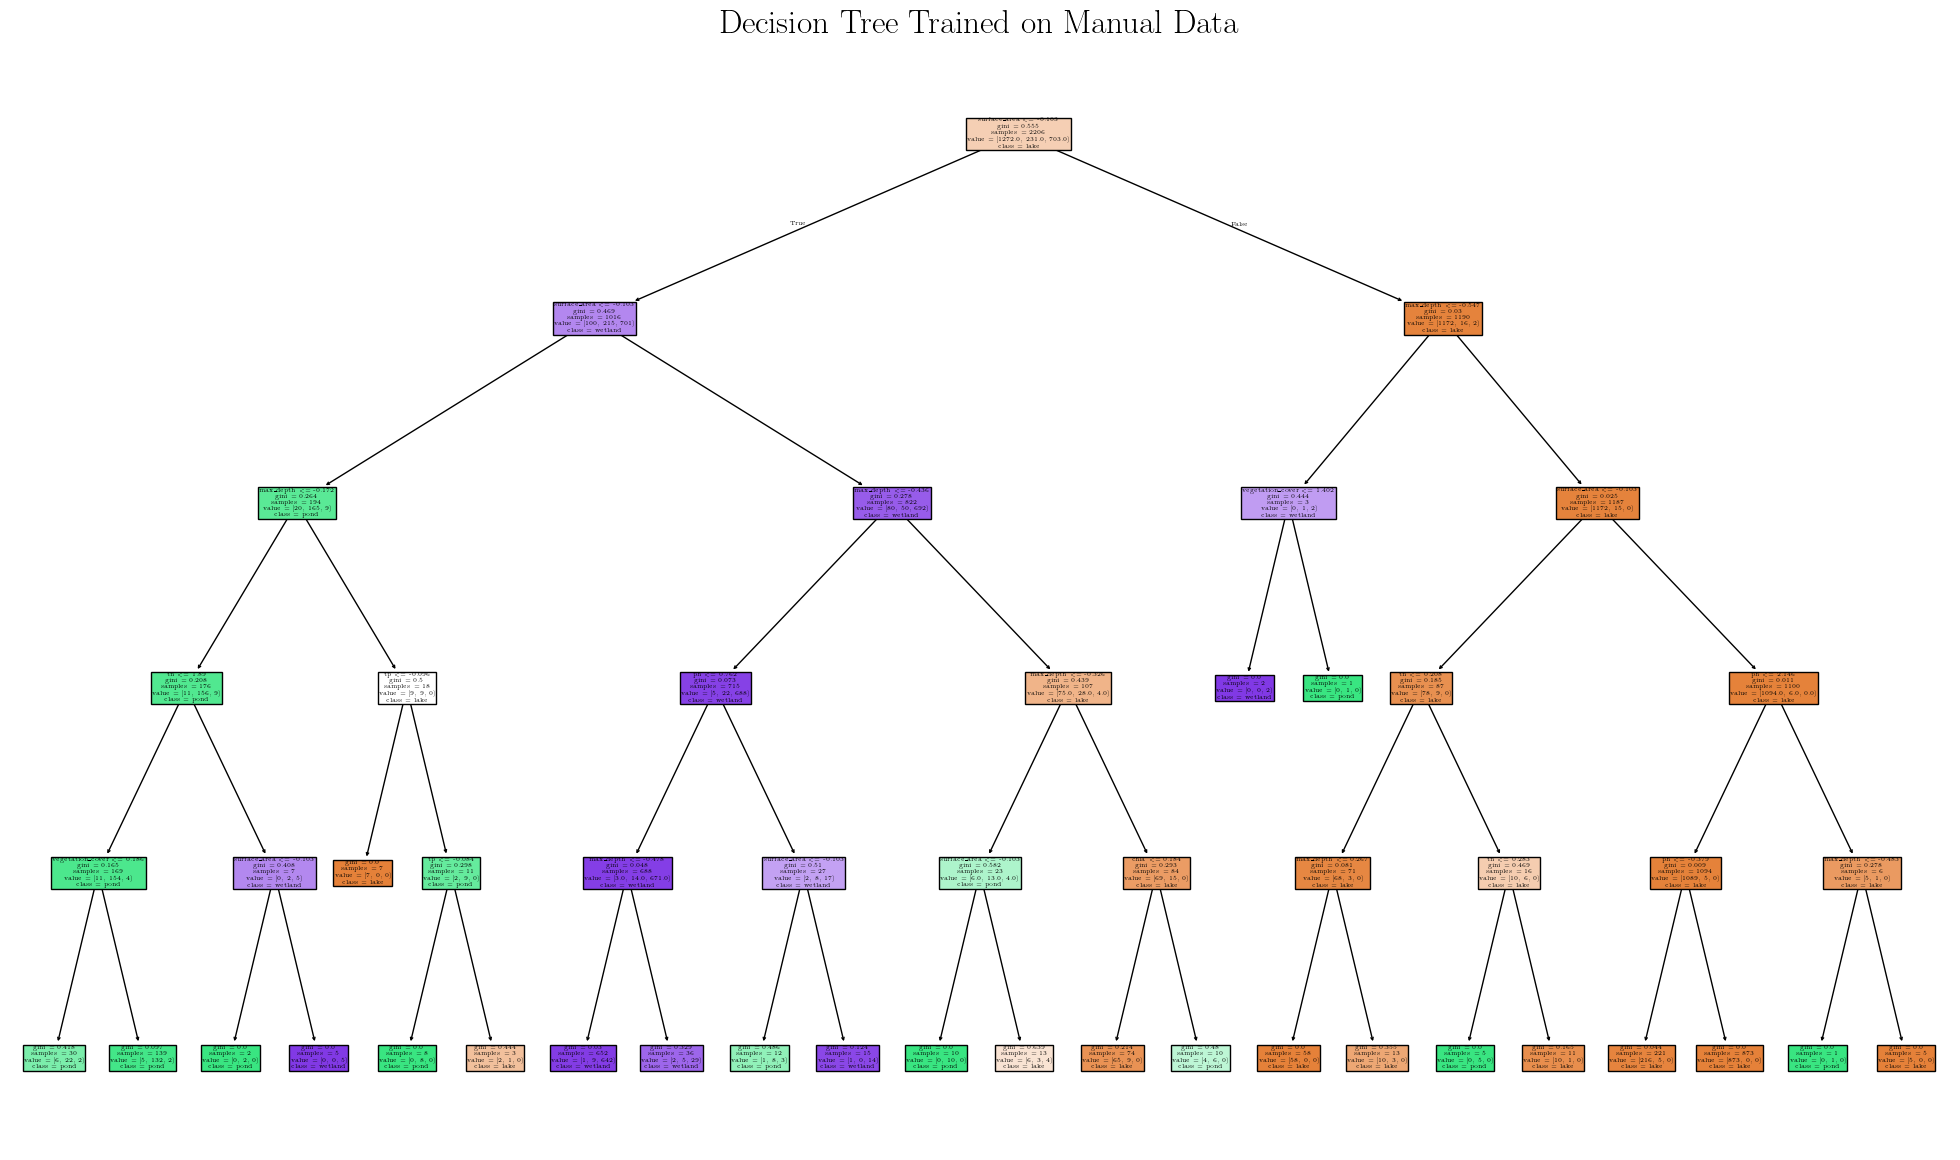

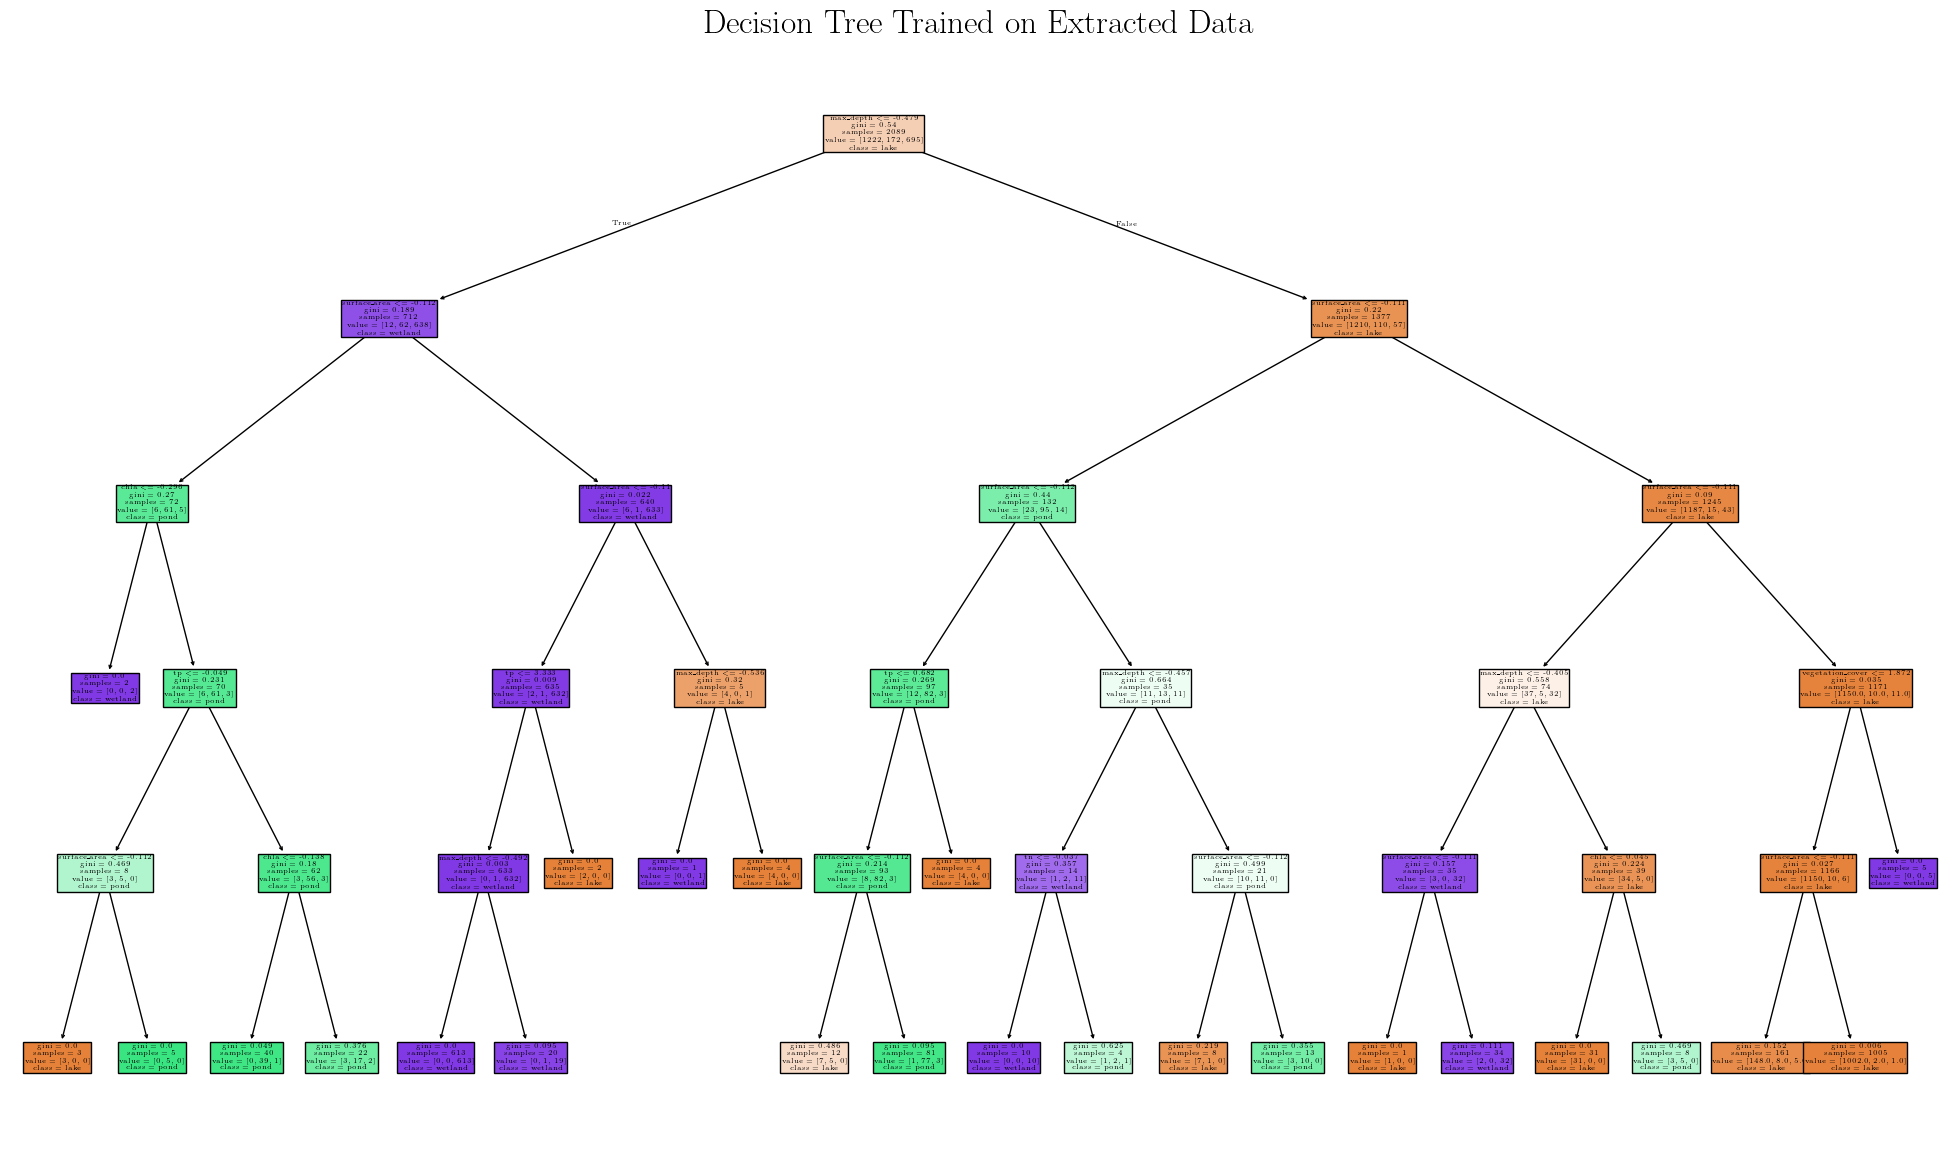

Baseline (manual tree on manual data): 0.5766
Extracted tree on manual data: 0.5766


In [53]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

##### Decision Tree

# Train decision tree on manual data
dt_manual = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_manual.fit(cleaned_data, labels)

# Train decision tree on extracted data
dt_extracted = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_extracted.fit(cleaned_extracted_data, extracted_labels)

# Visualize the manual data tree
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_manual, ax=ax, feature_names=['surface_area', 'max_depth', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
          class_names=['lake', 'pond', 'wetland'], filled=True)
plt.title('Decision Tree Trained on Manual Data')
plt.tight_layout()
plt.show()

# Visualize the extracted data tree
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_extracted, ax=ax, feature_names=['surface_area', 'max_depth', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
          class_names=['lake', 'pond', 'wetland'], filled=True)
plt.title('Decision Tree Trained on Extracted Data')
plt.tight_layout()
plt.show()

# Compute accuracies
accuracy_manual_on_manual = dt_manual.score(data, labels)
accuracy_extracted_on_manual = dt_extracted.score(data, labels)

print(f"Baseline (manual tree on manual data): {accuracy_manual_on_manual:.4f}")
print(f"Extracted tree on manual data: {accuracy_extracted_on_manual:.4f}")

##### Dimensionality Reduction

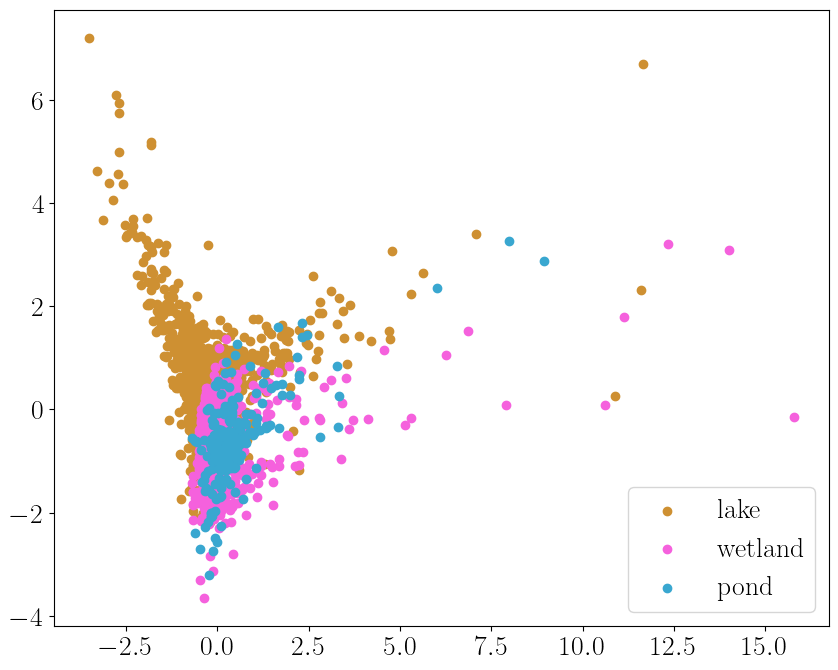

In [54]:
pca = PCA(n_components=2)
data_dim = pca.fit_transform(cleaned_data)

fig, ax = plt.subplots(figsize=(10, 8))
for ecotype in ['lake', 'wetland','pond']:
    idx = labels == ecotype
    ax.scatter(data_dim[idx,0], data_dim[idx,1], label=ecotype, color=color_dict[ecotype])

plt.legend()

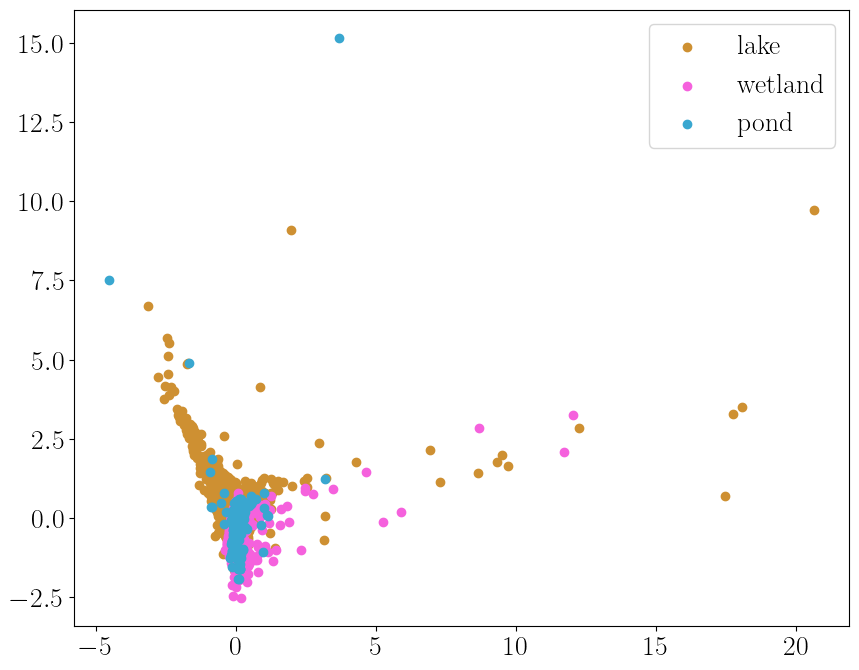

In [55]:
extracted_data_dim = pca.transform(cleaned_extracted_data)

fig, ax = plt.subplots(figsize=(10, 8))
for ecotype in ['lake', 'wetland','pond']:
    idx = extracted_labels == ecotype
    ax.scatter(extracted_data_dim[idx,0], extracted_data_dim[idx,1], label=ecotype, color=color_dict[ecotype])

plt.legend()

##### Clustering

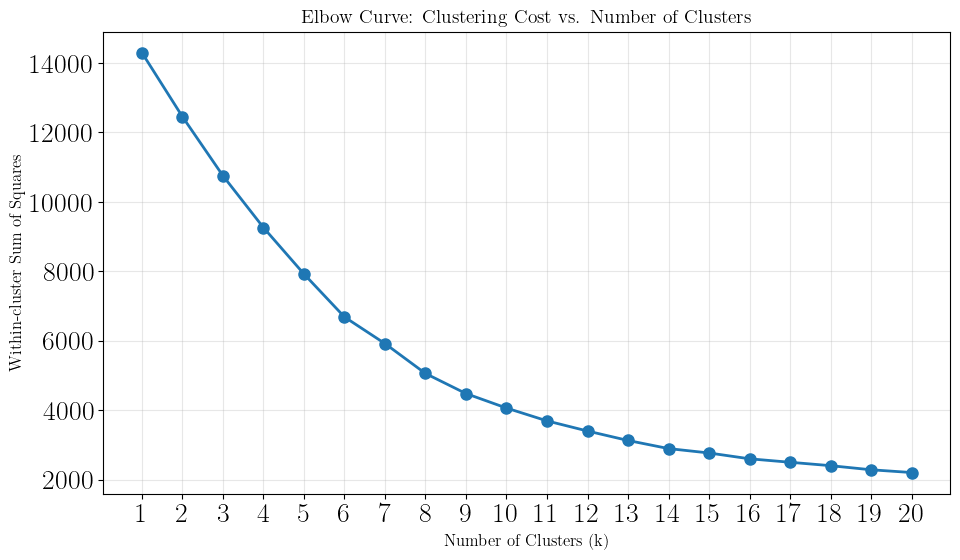

Inertia values for each k:
k=1: 14293.84
k=2: 12451.92
k=3: 10751.40
k=4: 9259.92
k=5: 7923.87
k=6: 6686.20
k=7: 5920.10
k=8: 5059.35
k=9: 4481.60
k=10: 4064.42
k=11: 3694.98
k=12: 3402.78
k=13: 3130.97
k=14: 2897.66
k=15: 2770.89
k=16: 2603.38
k=17: 2503.67
k=18: 2405.55
k=19: 2287.42
k=20: 2207.92


In [98]:
# Elbow curve analysis: examine clustering cost as a function of k
inertias = []
k_values = range(1, 21)  # Test k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cleaned_data)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, inertias, marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Within-cluster Sum of Squares', fontsize=12)
ax.set_title('Elbow Curve: Clustering Cost vs. Number of Clusters', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print('Inertia values for each k:')
for k, inertia in zip(k_values, inertias):
    print(f'k={k}: {inertia:.2f}')

In [100]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np

def centroid_matching_distance(A, B, metric='euclidean'):
    """
    A, B:       arrays of shape (k, d) and (m, d) — cluster centers
    labels_a/b: array of cluster assignments for each point
    points_a/b: array of shape (n, d) — original data points
    metric:     distance metric to use
    
    Returns:
        raw_dist:   mean matched distance
        norm_dist:  normalized by mean intra-cluster spread
        matching:   list of (i, j) center pairs
    """
    # Optimal assignment
    D = cdist(A, B, metric=metric)
    row_ind, col_ind = linear_sum_assignment(D, maximize=False)
    matched_distances = D[row_ind, col_ind]
    dist = matched_distances.mean()
    return dist

In [108]:
k = 9

# Baseline Clustering:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(cleaned_data)
cluster_centers = kmeans.cluster_centers_
cluster_labels = kmeans.labels_


# Iterating over confidence threshold clusterings:
centroid_distances = []
confidence_thresholds = np.linspace(0, 1.0, 11)
for threshold in confidence_thresholds:
    high_confidence_mask = extracted_confidence >= threshold
    filtered_extracted_data = cleaned_extracted_data[high_confidence_mask]

    kmeans_extracted = KMeans(n_clusters=k, random_state=42)
    kmeans_extracted.fit(filtered_extracted_data)
    cluster_centers_extracted = kmeans_extracted.cluster_centers_
    cluster_labels_extracted = kmeans_extracted.labels_

    distance = centroid_matching_distance(
        cluster_centers,
        cluster_centers_extracted,
    )
    centroid_distances.append(distance)

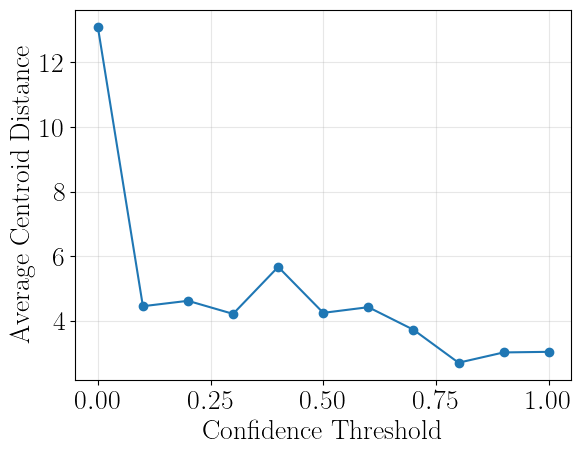

In [109]:
plt.plot(confidence_thresholds, centroid_distances, marker='o')
plt.xlabel('Confidence Threshold')
plt.ylabel('Average Centroid Distance')
plt.grid(alpha=0.3)
plt.show()

In [104]:
k = 9

# Baseline Clustering:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(cleaned_data)
cluster_centers = kmeans.cluster_centers_
cluster_labels = kmeans.labels_


# Iterative outlier removal based on distance-to-center weighted by (1 - confidence):
centroid_distances = []
num_points_removed = []
max_removals = 100

# Start with full extracted dataset
current_extracted_data = cleaned_extracted_data.copy()
current_extracted_confidence = extracted_confidence.copy()
current_extracted_labels = extracted_labels.copy()
remaining_indices = np.arange(len(extracted_labels))

while len(current_extracted_data) > 0:
    # Perform clustering on current data
    kmeans_extracted = KMeans(n_clusters=k, random_state=42)
    kmeans_extracted.fit(current_extracted_data)
    cluster_centers_extracted = kmeans_extracted.cluster_centers_
    cluster_labels_extracted = kmeans_extracted.labels_

    # Compute distance to assigned cluster center for each point
    distances_to_center = np.array([
        np.linalg.norm(current_extracted_data[i] - cluster_centers_extracted[cluster_labels_extracted[i]])
        for i in range(len(current_extracted_data))
    ])

    # Compute weighted outlier score: distance * (1 - confidence)
    outlier_scores = distances_to_center * (1 - current_extracted_confidence)

    # Compute matching distance with baseline
    centroid_distance = centroid_matching_distance(
        cluster_centers,
        cluster_centers_extracted,
    )
    centroid_distances.append(centroid_distance)
    num_points_removed.append(len(extracted_labels) - len(current_extracted_data))

    # Check if we've reached the removal limit
    if num_points_removed[-1] >= max_removals:
        break

    # Remove 10 points with highest outlier scores
    if len(current_extracted_data) > 0:
        num_to_remove = min(10, len(current_extracted_data))
        top_outlier_indices = np.argsort(outlier_scores)[-num_to_remove:]
        # Sort in descending order to remove from highest index first (to maintain correct indices)
        top_outlier_indices = np.sort(top_outlier_indices)[::-1]
        for idx in top_outlier_indices:
            current_extracted_data = np.delete(current_extracted_data, idx, axis=0)
            current_extracted_confidence = np.delete(current_extracted_confidence, idx)
            current_extracted_labels = np.delete(current_extracted_labels, idx)
    else:
        break

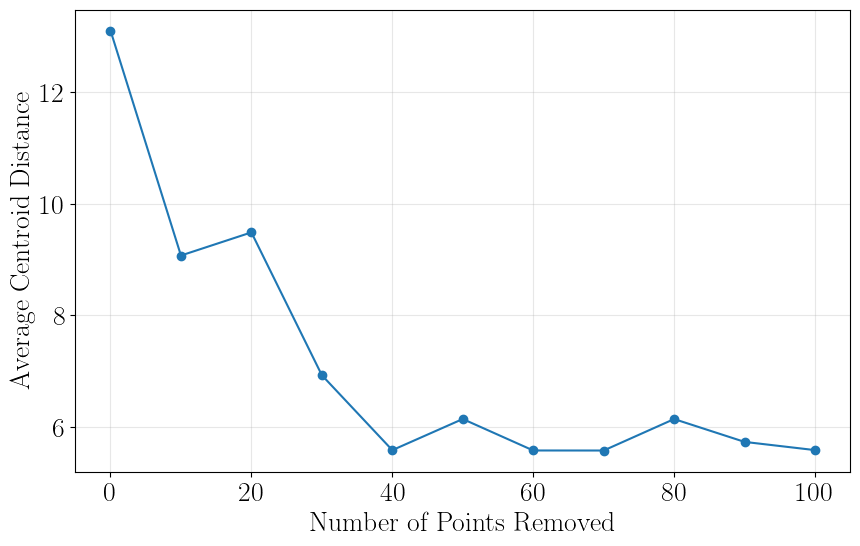

In [107]:
plt.figure(figsize=(10, 6))
plt.plot(num_points_removed, centroid_distances, marker='o')
plt.xlabel('Number of Points Removed')
plt.ylabel('Average Centroid Distance')
plt.grid(alpha=0.3)
plt.show()

In [79]:
len(cleaned_extracted_data)

2089